# Understanding the 1D Finite Element Method

The Finite Element Method (FEM) is a numerical method for approximating solutions to partial differential equations by discretising the domain into smaller subdomains (finite elements) and constructing a piecewise approximation over them (i.e., representing the global solution using simple element-level functions assembled to form a continuous approximation).

| **Formal Term**       | **Symbol**         | **Definition**                                                                                         |
| --------------------- | ------------------ | ------------------------------------------------------------------------------------------------------ |
| Domain                | $\Omega$           | Physical space (e.g., a bar of length $L$).                                                            |
| Reference Element     | $\hat{K}$          | Standardised domain, usually the interval $[-1, 1]$.                                                   |
| Physical Element      | $K_e$              | A specific sub-section of the actual mesh.                                                             |
| Basis Functions       | $N_i(\xi)$         | Functions used to interpolate values across an element.                                                |
| Isoparametric Mapping | $\mathcal{x}(\xi)$ | Function mapping reference coordinates $\xi$ to physical coordinates $x$ in the element.               |
| Jacobian              | $J$                | Derivative of the isoparametric mapping ($J = d\mathcal{x}/d\xi$), representing local element scaling. |
| Physical Coordinate   | $x$                | Spatial position in the physical domain $\Omega$, obtained from $\xi$ via $\mathcal{x}(\xi)$.          |
| Reference Coordinate  | $\xi$              | Local dimensionless coordinate on the reference element $\hat{K}$ (typically $\xi \in [-1,1]$).        |

[Introduction to the Finite Element Method (FEM)](https://www.ccg.msm.cam.ac.uk/system/files/documents/FEMOR_Lecture_2.pdf)



Nodal displacements: [0.00000000e+00 1.19047619e-06 2.38095238e-06 3.57142857e-06
 4.76190476e-06 5.95238095e-06 7.14285714e-06 8.33333333e-06
 9.52380952e-06]


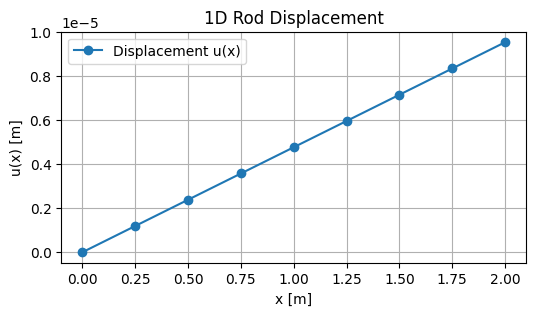

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Callable

# -------------------------------
# Classes
# -------------------------------

class Domain:
    """Physical domain Ω."""
    def __init__(self, length: float) -> None:
        self.length: float = length

class PhysicalElement:
    """Physical element Ke with nodes and material properties."""
    def __init__(self, nodes: List[float], E: float, A: float) -> None:
        self.nodes: np.ndarray = np.array(nodes, dtype=float)
        self.E: float = E  # Young's modulus
        self.A: float = A  # Cross-sectional area

class BasisFunction:
    """Linear basis function N_i(ξ) for interpolation."""
    def __init__(self, func: Callable[[float], float], derivative: Callable[[float], float]) -> None:
        self.func = func
        self.derivative = derivative

    def __call__(self, xi: float) -> float:
        return self.func(xi)

    def dxi(self, xi: float) -> float:
        return self.derivative(xi)

class IsoparametricMapping:
    """Maps ξ → x and computes Jacobian."""
    def __init__(self, element: PhysicalElement, basis_functions: List[BasisFunction]) -> None:
        self.element = element
        self.basis_functions = basis_functions

    def map(self, xi: float) -> float:
        return sum(node_val * N(xi) for node_val, N in zip(self.element.nodes, self.basis_functions))

    def jacobian(self, xi: float) -> float:
        return sum(node_val * N.dxi(xi) for node_val, N in zip(self.element.nodes, self.basis_functions))

# -------------------------------
# FEM Solver for 1D rod
# -------------------------------

class RodFEM:
    """Finite element solver for a 1D rod."""
    def __init__(self, nodes: List[float], E: float, A: float) -> None:
        self.nodes = np.array(nodes, dtype=float)
        self.n_nodes = len(nodes)
        self.E = E
        self.A = A
        self.elements: List[PhysicalElement] = []
        self.u: np.ndarray = np.zeros(self.n_nodes)
        self.K_global: np.ndarray = np.zeros((self.n_nodes, self.n_nodes))
        self.F_global: np.ndarray = np.zeros(self.n_nodes)

        # Create elements between consecutive nodes
        for i in range(self.n_nodes - 1):
            elem_nodes = [self.nodes[i], self.nodes[i+1]]
            self.elements.append(PhysicalElement(elem_nodes, E, A))

        # Linear 2-node basis functions
        self.N1 = BasisFunction(lambda xi: 0.5*(1 - xi), lambda xi: -0.5)
        self.N2 = BasisFunction(lambda xi: 0.5*(1 + xi), lambda xi: 0.5)
        self.basis_functions = [self.N1, self.N2]

    def assemble(self) -> None:
        """Assemble global stiffness matrix."""
        for e_idx, elem in enumerate(self.elements):
            mapping = IsoparametricMapping(elem, self.basis_functions)
            # Element stiffness matrix
            K_e = np.zeros((2,2))
            # Single-point Gauss quadrature for linear element
            xi_gp = [0.0]
            w_gp = [2.0]
            for xi, w in zip(xi_gp, w_gp):
                J = mapping.jacobian(xi)
                dN_dx = np.array([N.dxi(xi)/J for N in self.basis_functions])
                K_e += np.outer(dN_dx, dN_dx) * elem.E * elem.A * J * w

            # Assemble into global matrix
            dof = [e_idx, e_idx+1]
            for i_local, i_global in enumerate(dof):
                for j_local, j_global in enumerate(dof):
                    self.K_global[i_global, j_global] += K_e[i_local, j_local]

    def apply_force(self, node: int, value: float) -> None:
        self.F_global[node] = value

    def apply_dirichlet_bc(self, node: int, value: float) -> None:
        """Apply displacement BC by modifying K and F (penalty method)."""
        self.K_global[node,:] = 0.0
        self.K_global[:,node] = 0.0
        self.K_global[node,node] = 1.0
        self.F_global[node] = value

    def solve(self) -> np.ndarray:
        self.u = np.linalg.solve(self.K_global, self.F_global)
        return self.u

    def plot_displacement(self) -> None:
        plt.figure(figsize=(6,3))
        plt.plot(self.nodes, self.u, '-o', label='Displacement u(x)')
        plt.xlabel('x [m]')
        plt.ylabel('u(x) [m]')
        plt.title('1D Rod Displacement')
        plt.grid(True)
        plt.legend()
        plt.show()

# -------------------------------
# Example: rod of length 2 m, 2 elements, fixed left end, force on right end
# -------------------------------
nodes = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
E = 210e9  # Pa (steel)
A = 0.01   # m^2
F = 1e4    # N

rod = RodFEM(nodes, E, A)
rod.assemble()
rod.apply_dirichlet_bc(node=0, value=0.0)  # fixed left end
rod.apply_force(node=-1, value=F)          # force at right end
u = rod.solve()
print("Nodal displacements:", u)
rod.plot_displacement()

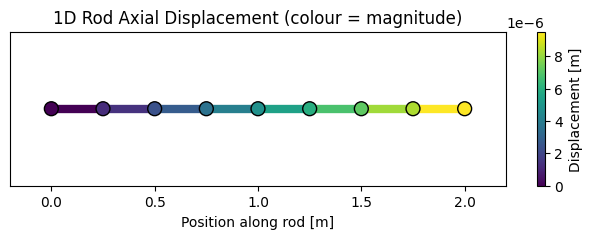

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def plot_rod_displacement(nodes: np.ndarray, u: np.ndarray) -> None:
    """
    Plot 1D rod as a horizontal line coloured by displacement.
    nodes : nodal coordinates (x)
    u     : nodal displacements
    """
    # Create line segments between nodes
    segments = [[(nodes[i], 0), (nodes[i+1], 0)] for i in range(len(nodes)-1)]
    u_avg = [(u[i] + u[i+1])/2 for i in range(len(u)-1)]  # average displacement for colour

    # LineCollection coloured by displacement
    lc = LineCollection(segments, array=np.array(u_avg), cmap='viridis', linewidths=6)
    fig, ax = plt.subplots(figsize=(8,2))
    ax.add_collection(lc)

    # Node markers coloured by displacement
    sc = ax.scatter(nodes, np.zeros_like(nodes), c=u, cmap='viridis', s=100, edgecolors='k', zorder=3)

    ax.set_xlim(nodes[0]-0.1*(nodes[-1]-nodes[0]), nodes[-1]+0.1*(nodes[-1]-nodes[0]))
    ax.set_yticks([])  # remove y-axis ticks
    ax.set_xlabel('Position along rod [m]')
    ax.set_title('1D Rod Axial Displacement (colour = magnitude)')

    # Colourbar
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('Displacement [m]')
    plt.show()

# Example usage
plot_rod_displacement(np.array(nodes), u)